CEE 551 Homework 4

Problem 1  -  Fitting a Gamma distribution to flood damage data

In [32]:
import pandas as pd
import numpy as np
from scipy.stats import gamma
import matplotlib.pyplot as plt

In [33]:
# Load the Excel file
file_path = "damages.xlsx" 
df = pd.read_excel(file_path)

# Display the first few rows
print(df.head())

   record  damage
0       1  16.005
1       2   5.566
2       3   5.560
3       4  12.127
4       5   4.322


1a - Finding the 95th percentile of these data using Bernard’s formula:

In [34]:
# Sort the damage values in ascending order
df = df.sort_values(by="damage").reset_index(drop=True)

#Set up Equation
# Get the number of records
n = len(df)
# Compute empirical cumulative probabilities using Bernard's approximation
df["F_hat"] = (df.index + 1 - 0.3) / (n + 0.4) #this is just the equation in python 
# Find the damage value corresponding to the 95th percentile
percentile_95 = df.loc[df["F_hat"] >= 0.95, "damage"].iloc[0] #filter F_hat to 95th and put into a variable

print(f"95th percentile damage value: {percentile_95}") # text and variable printing

95th percentile damage value: 26.206


1b - Finding alpha and beta of the gamma distribution using maximum log likelihood

In [35]:
#alpha is the shape parameter Beta is the scale parameter

# Extract the "damage" column
damage_data = df["damage"].values

# Fit Gamma distribution using MLE
shape, loc, scale = gamma.fit(damage_data, floc=0)  # Force location parameter to 0
#how it works internally - Intial Guess of a & b (method of moments)
#

# Alpha (shape) and Beta (scale)
alpha = round(shape) #added round to contrain to integer values
beta = round(scale)  # In SciPy, scale = 1/rate = 1/lambda

print(f"Estimated Alpha (Shape): {alpha}")
print(f"Estimated Beta (Scale): {beta}")

Estimated Alpha (Shape): 2
Estimated Beta (Scale): 5


1c - Filter dataset to those above the 95th percentile apply gamma funtion with a = 2 and b = 5 to make characteristic extreme x20 meaning value that is expected to be exceeded 1 in 20 times

In [36]:
# Filter values above the 95th percentile
extreme_df = df[df["damage"] > percentile_95].copy()

# Apply Gamma function transformation with a=2, b=5 to exaggerate extremes
a, b = 2, 5
extreme_df["damage_transformed"] = gamma.pdf(extreme_df["damage"].to_numpy(), a, scale=b) #this is my gamma values?
# Display results
print(extreme_df[["damage", "damage_transformed"]])

     damage  damage_transformed
520  26.294            0.005471
521  26.864            0.004987
522  27.432            0.004546
523  27.704            0.004348
524  28.027            0.004123
525  28.428            0.003860
526  28.872            0.003587
527  28.883            0.003581
528  29.563            0.003199
529  29.821            0.003065
530  30.301            0.002829
531  30.378            0.002793
532  31.445            0.002335
533  31.770            0.002211
534  31.798            0.002200
535  32.449            0.001971
536  32.944            0.001813
537  33.075            0.001773
538  33.597            0.001622
539  33.950            0.001528
540  35.454            0.001181
541  36.274            0.001026
542  37.424            0.000841
543  37.651            0.000808
544  39.241            0.000613
545  40.220            0.000516


1b Make exceedance value then plot intensity function for the top 5 percent 

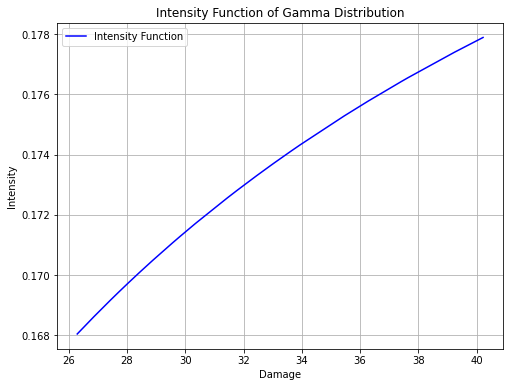

In [37]:
#calculate exceedance probability
extreme_df["exceedance_probability"] = gamma.sf(extreme_df["damage"].to_numpy(), a, scale=b) #function in scripy

damage_values = extreme_df["damage"].to_numpy()
damage_transformed = extreme_df["damage_transformed"].to_numpy()
exceedance_probability = extreme_df["exceedance_probability"].to_numpy()

# Calculate the intensity function
intensity = damage_transformed / exceedance_probability #from powerpoint

# Plotting the intensity function
plt.figure(figsize=(8, 6))
plt.plot(damage_values, intensity, label="Intensity Function", color='b')
plt.title("Intensity Function of Gamma Distribution")
plt.xlabel("Damage")
plt.ylabel("Intensity")
plt.grid(True)
plt.legend()
plt.show()

2 - Deriving the Gumbel distribution for maximum damage values

2a  density function of the gumbel distribution representign the distribution of maximum values from problem 1
Smaple sizes 10 100 10000 
What type of class is this distribution?

Am I supposed to use

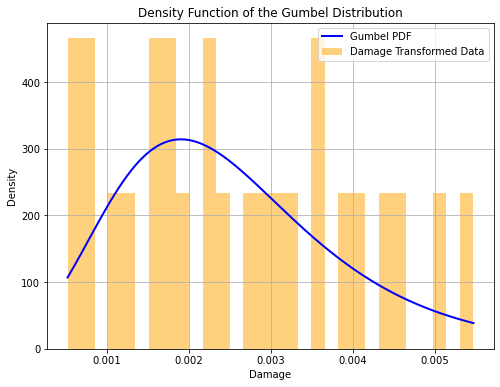

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gumbel_r

# Ensure the "damage_transformed" 
damage_transformed = extreme_df["damage_transformed"].to_numpy()

#use the function from scripy
mu, beta = gumbel_r.fit(damage_transformed)

# Generate a range of values for plotting the density function
x_values = np.linspace(min(damage_transformed), max(damage_transformed), 1000)

# Compute the Gumbel density function (PDF) for the generated x values 
#this estimates the 
gumbel_pdf = gumbel_r.pdf(x_values, mu, beta)

# Plot the Gumbel distribution density function
plt.figure(figsize=(8, 6))
plt.plot(x_values, gumbel_pdf, label='Gumbel PDF', color='blue', lw=2)
plt.hist(damage_transformed, bins=30, density=True, alpha=0.5, label='Damage Transformed Data', color='orange')
plt.xlabel('Damage')
plt.ylabel('Density')
plt.title('Density Function of the Gumbel Distribution')
plt.legend()
plt.grid(True)
plt.show()

# this is Type E1

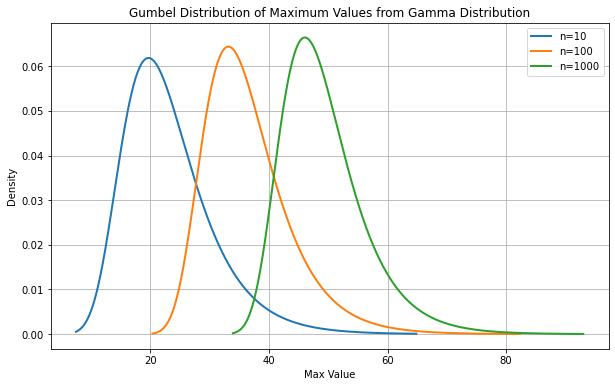

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gamma, gumbel_r

damage_transformed = extreme_df["damage_transformed"].to_numpy()
# Set parameters for the Gamma distribution (shape and scale)
shape, scale = 2, 5  

# Define sample sizes for max distribution
sample_sizes = [10, 100, 1000]
num_samples = 10000  # Number of times we take samples

plt.figure(figsize=(10, 6))

for n in sample_sizes:
    # Generate multiple samples from a Gamma distribution
    samples = gamma.rvs(shape, scale=scale, size=(num_samples, n))

    # Take the maximum value from each sample
    max_values = samples.max(axis=1)

    # Fit the Gumbel distribution to the max values
    mu, beta = gumbel_r.fit(max_values)

    # Generate x-values for density plot
    x_values = np.linspace(min(max_values), max(max_values), 1000)

    # Compute the fitted Gumbel density function (PDF)
    gumbel_pdf = gumbel_r.pdf(x_values, mu, beta)

    # Plot the density function
    plt.plot(x_values, gumbel_pdf, label=f'n={n}', lw=2)

plt.xlabel('Max Value')
plt.ylabel('Density')
plt.title('Gumbel Distribution of Maximum Values from Gamma Distribution')
plt.legend()
plt.grid(True)
plt.show()


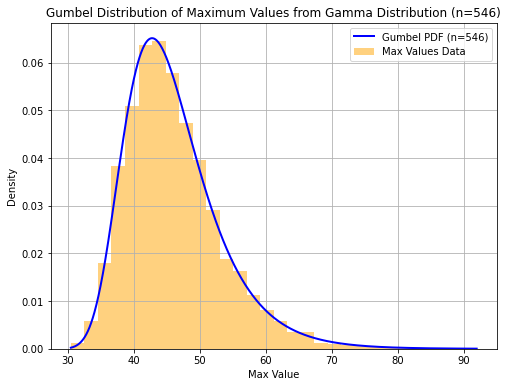

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gamma, gumbel_r

# Set parameters for the Gamma distribution (shape and scale)
shape, scale = 2, 5  # Adjust if needed
n = 546  # Sample size for max distribution
num_samples = 10000  # Number of times we take samples

# Generate multiple samples from a Gamma distribution
samples = gamma.rvs(shape, scale=scale, size=(num_samples, n))

# Take the maximum value from each sample
max_values = samples.max(axis=1)

# Fit the Gumbel distribution to the max values
mu, beta = gumbel_r.fit(max_values)

# Generate x-values for density plot
x_values = np.linspace(min(max_values), max(max_values), 1000)

# Compute the fitted Gumbel density function (PDF)
gumbel_pdf = gumbel_r.pdf(x_values, mu, beta)

# Plot the density function
plt.figure(figsize=(8, 6))
plt.plot(x_values, gumbel_pdf, label=f'Gumbel PDF (n=546)', color='blue', lw=2)
plt.hist(max_values, bins=30, density=True, alpha=0.5, label='Max Values Data', color='orange')
plt.xlabel('Max Value')
plt.ylabel('Density')
plt.title('Gumbel Distribution of Maximum Values from Gamma Distribution (n=546)')
plt.legend()
plt.grid(True)
plt.show()


2b. What is the probability of the maximum value in a sample of this size being as great or greater
than the maximum observed value in your dataset?

3 - Fitting a Generalized Pareto Distribution (GPD) lecture 13

In [3]:
# Load the Excel file
file_path = "damages.xlsx" 
df = pd.read_excel(file_path)

# Display the first few rows
print(df.head())

   record  damage
0       1  16.005
1       2   5.566
2       3   5.560
3       4  12.127
4       5   4.322


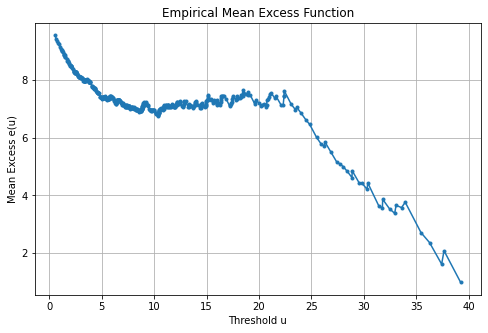

In [4]:
damage = df["damage"].sort_values().values  # Sort the damage values

# Define the empirical excess function
mean_excess = []
thresholds = damage  # Use each value as a threshold

for u in thresholds:
    exceedances = damage[damage > u]
    if len(exceedances) > 0:
        mean_excess.append(np.mean(exceedances - u))
    else:
        mean_excess.append(np.nan)  # No exceedances

# Plot the mean excess function
plt.figure(figsize=(8, 5))
plt.plot(thresholds, mean_excess, marker='o', linestyle='-', markersize=3)
plt.xlabel("Threshold u")
plt.ylabel("Mean Excess e(u)")
plt.title("Empirical Mean Excess Function")
plt.grid()
plt.show()

3b The graph decreases linearly around 23

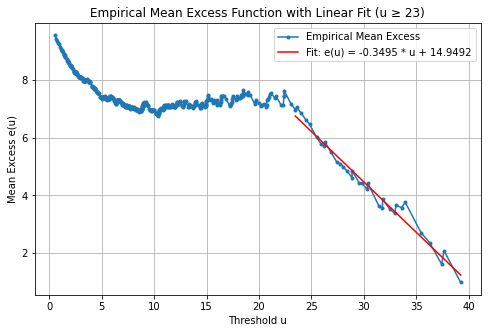

Slope: -0.3495
Intercept: 14.9492


In [13]:
from scipy.stats import linregress

thresholds = np.array(thresholds)
mean_excess = np.array(mean_excess)
mask = (thresholds >= 23) & (mean_excess <= 7)
x_fit = thresholds[mask]
y_fit = mean_excess[mask]


# Perform linear regression
slope, intercept, r_value, p_value, std_err = linregress(x_fit, y_fit)

# Plot the mean excess function
plt.figure(figsize=(8, 5))
plt.plot(thresholds, mean_excess, marker='o', linestyle='-', markersize=3, label="Empirical Mean Excess")
plt.plot(x_fit, slope * x_fit + intercept, color='red', label=f"Fit: e(u) = {slope:.4f} * u + {intercept:.4f}")
plt.xlabel("Threshold u")
plt.ylabel("Mean Excess e(u)")
plt.title("Empirical Mean Excess Function with Linear Fit (u ≥ 23)")
plt.legend()
plt.grid()
plt.show()

# Report the slope and intercept
print(f"Slope: {slope:.4f}")
print(f"Intercept: {intercept:.4f}")

In [ ]:
#3f
# shape parameter is slope/(1+slope) = -.5374
# Scale parameter is intercept * (1-shape_parameter) = 22.98

In [15]:
#3g
# Given parameter estimates
xi = -0.5374  # Shape parameter
phi = 22.9846  # Scale parameter
p = 0.95  # Confidence level

# Load dataset (replace with actual data)
damage = np.array(df["damage"])  # Replace with actual damage values

# Compute 95th percentile threshold
u = np.percentile(damage, 95)

# Total number of observations
n = len(damage)

# Number of exceedances above threshold
N_u = np.sum(damage > u)

# Compute VaR_0.95 using the given formula
VaR_95 = u + (phi / xi) * (((n / N_u) * (1 - p)) ** (-xi) - 1)

print(f"95% Value at Risk (VaR_0.95): {VaR_95:.4f}")
#value is a little further then my estimates

95% Value at Risk (VaR_0.95): 26.3950


In [16]:
#3h plug and chugg

if xi < 1:  # Condition for expectation to be finite
    CVaR_95 = VaR_95 + (phi + xi * (VaR_95 - u)) / (1 - xi)
    print(f"95% Conditional Value at Risk (CVaR_0.95): {CVaR_95:.4f}")
else:
    print("CVaR is undefined for ξ ≥ 1 as expected shortfall is infinite.")


95% Conditional Value at Risk (CVaR_0.95): 41.1433


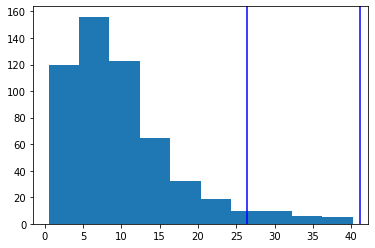

In [20]:
#3i Histogram

plt.hist(damage)

plt.axvline(x = VaR_95, color = 'b', label = 'axvline - full height')
plt.axvline(x = CVaR_95, color = 'b', label = 'axvline - full height')
 
plt.show() 

In [28]:

var_damage_mask = (damage >= 23) 
var_damage = damage[var_damage_mask]
answer = len(damage)/len(var_damage)
var_damage
print(f"percent of values above VaR_0.95): {answer:.4f}")

percent of values above VaR_0.95): 15.6000


Problem 4 - Fitting a Weibull Distribution to Failure Time Data

In [18]:
# Load the Excel file
file_path = "failures.xlsx" 
df = pd.read_excel(file_path)

# Display the first few rows
print(df.head())

   sample  failure time
0       1           276
1       2           238
2       3           380
3       4           142
4       5            41


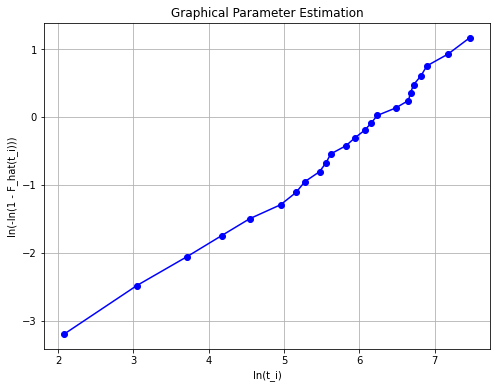

In [21]:
#4a graphical parameter method if linear weibull is a good fit
#  Sort the failure times
df_sorted = df.sort_values(by='failure time')

# Compute the empirical CDF (F_hat)
n = len(df_sorted)
df_sorted['F_hat'] = (np.arange(1, n + 1)) / n

# Apply Bernoulli's formula and calculate ln(-ln(1 - F_hat))
df_sorted['ln_F_hat'] = np.log(np.log(1 / (1 - df_sorted['F_hat'])))

# Calculate ln(t_i)
df_sorted['ln_t'] = np.log(df_sorted['failure time'])

ln_t = df_sorted['ln_t'].to_numpy()
ln_F_hat = df_sorted['ln_F_hat'].to_numpy()

# Step 6: Plot the graph
plt.figure(figsize=(8, 6))
plt.plot(ln_t, ln_F_hat, marker='o', linestyle='-', color='b')
plt.xlabel('ln(t_i)')
plt.ylabel('ln(-ln(1 - F_hat(t_i)))')
plt.title('Graphical Parameter Estimation')
plt.grid(True)
plt.show()

In [25]:
from sklearn.linear_model import LinearRegression

#added to remove stuff
df_sorted = df_sorted.replace([np.inf, -np.inf], np.nan).dropna(subset=['ln_F_hat', 'ln_t'])

# Step 5: Perform linear regression (ln_F_hat vs ln_t)
X = df_sorted['ln_t'].values.reshape(-1, 1)  # Predictor: ln(t)
y = df_sorted['ln_F_hat'].values  # Response: ln(-ln(1 - F_hat))

# Create and fit the model
regressor = LinearRegression()
regressor.fit(X, y)

# Step 6: Extract the Weibull parameters from the regression
beta_est = regressor.coef_[0]  # Shape parameter (beta)
ln_lambda_est = -regressor.intercept_ / beta_est  # Scale parameter (lambda)

lambda_est = np.exp(ln_lambda_est)

# Step 7: Output the estimated parameters
print(f"Estimated Weibull Shape Parameter (k): {beta_est:.4f}")
print(f"Estimated Weibull Scale Parameter (lambda): {lambda_est:.4f}")

Estimated Weibull Shape Parameter (k): 0.8258
Estimated Weibull Scale Parameter (lambda): 520.8725


#4c
Hazard rate depends on the shape parameter in our case the shape parameter is less than 1 there for the hazard rate is decreasing followinf an early life failure part of the weibull curve